# Image-Based Authentication Pipeline

This section of the project focuses on implementing the facial recognition component of the multimodal authentication system. The goal is to train a machine learning model capable of identifying users based on facial images.




The pipeline consits of the following stages:

1. Loading and organizing image data for each user
2. Applying image augmentations to increase dataset diversity
3. Extracting numerical features from images using color histograms
4. Storing the extracted features in a structured dataset
5. Training a machine learning model to recognize users
6. Evaluating the model using classification metrics




This process converst raw image data into numerical representations that a machine learning model can use for user identification.

### Import Required Libraries

This section imports the necessary Python libraries used throughout the image preprocessing and model training pipeline.


- cv2 is used for image loading, augmentation, and feature extraction.
- NumPy is used for numerical operations.
- Pandas is used to organize extracted features into a structured dataset.
- Matplotlib is used to visualize images and augmentations.
- Scikit-learn is used o train and evaluate the machine learning model.


In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
import sklearn
import joblib

### Image Loading and Data Augmentation

In this step, facial images for each user are loaded from the dataset directory. Each user folder contains images representing different facial expressions such as neutral, smiling, and surprised.

To improve the robustness of the model and simulate real-world conditions, several image augmentations are applied:

- **Horizontal flipping** to simulate mirrored facial positions
- **Rotation** to represent slight changes in head orientation
- **Grayscale conversion** to reduce reliance on color and emphasize structural features

These augmentations increase the effective size of the dataset and help the model generalize better when recognizing faces.

The augmented images are also visualized to confirm that the transformations were applied correctly.

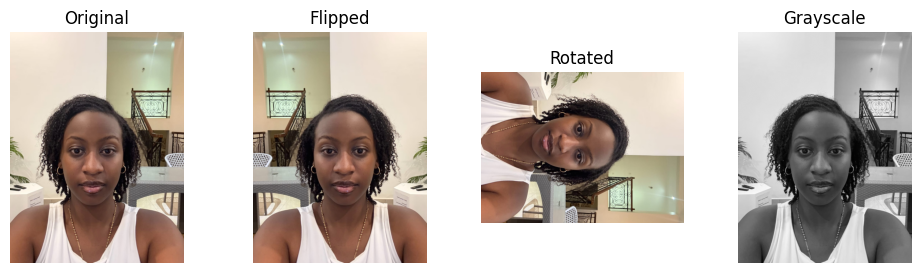

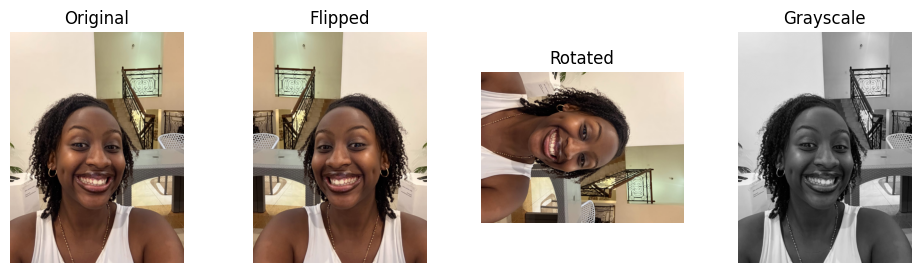

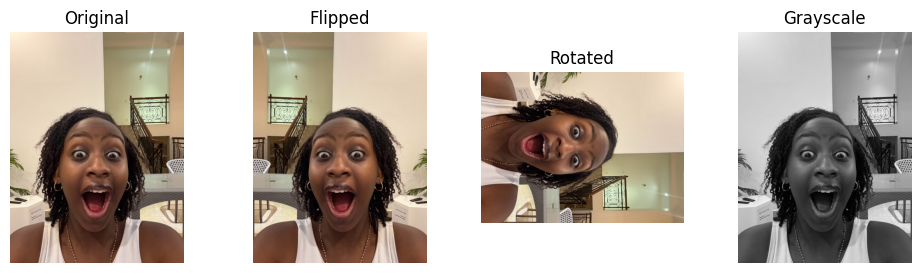

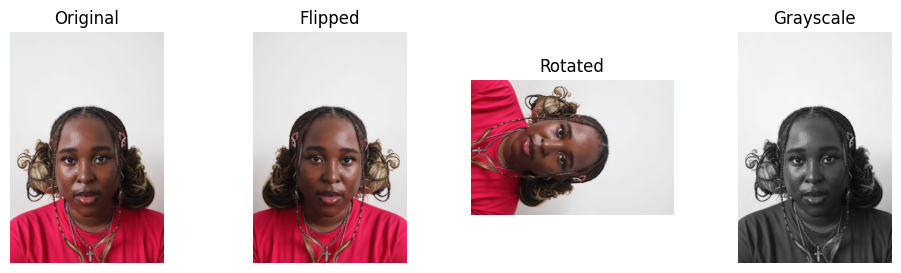

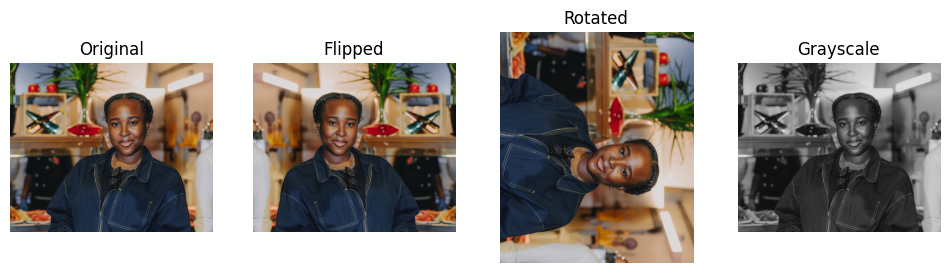

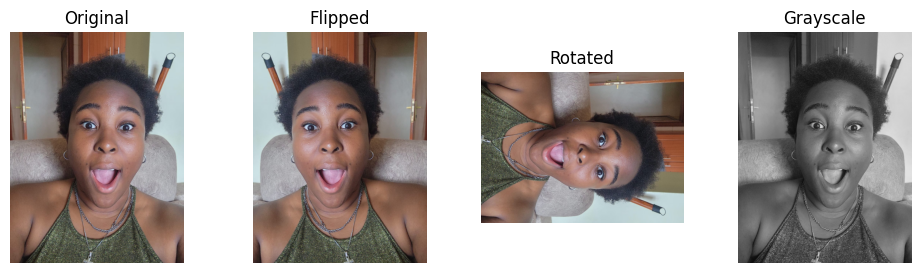

In [ ]:
base_path = "data/raw-images"

valid_extensions = ('.jpg', '.jpeg', '.png', '.DNG')

for person in os.listdir(base_path):
    person_folder = os.path.join(base_path, person)

    for image_name in os.listdir(person_folder):
        image_path = os.path.join(person_folder, image_name)

        img = cv2.imread(image_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        flipped = cv2.flip(img, 1)
        rotated = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        plt.figure(figsize=(12,3))
        plt.subplot(1,4,1)
        plt.imshow(img)
        plt.title("Original")
        plt.axis("off")

        plt.subplot(1,4,2)
        plt.imshow(flipped)
        plt.title("Flipped")
        plt.axis("off")

        plt.subplot(1,4,3)
        plt.imshow(rotated)
        plt.title("Rotated")
        plt.axis("off")

        plt.subplot(1,4,4)
        plt.imshow(gray, cmap="gray")
        plt.title("Grayscale")
        plt.axis("off")

        plt.show()

### Feature Extraction
Machine learning models cannot directly process raw images, so each image must be converted into a numerical representation.

In this project, a **color histogram** is used to represent each image. A color histogram captures the distribution of pixel intensities across the red, green, and blue channels.

The histogram is computed using:

- **8 bins per color channel (RGB)**  
- Producing a **3D histogram of size 8 × 8 × 8**

This results in a **512-dimensional feature vector** for every image.

The histogram is then flattened into a one-dimensional vector so it can be used as input for machine learning algorithms.

In [ ]:
def extract_features(img):
  hist = cv2.calcHist([img],[0,1,2],None,[8,8,8],[0,256,0,256,0,256])
  hist = hist.flatten()  #converts 3D histogram to 1D vector
  return hist

### Creating the Image Feature Dataset

After defining the feature extraction method, the next step is to apply it to all images in the dataset.

For each user image:
1. The image is loaded
2. Augmentations are applied (flip, rotate, grayscale)
3. Features are extracted from the original and augmented images
4. The extracted features are stored along with the user label

The resulting dataset contains:

- A **user label** identifying the person in the image
- The **augmentation type**
- **512 numerical feature values** representing the image

All extracted features are stored in a CSV file (`image_features.csv`) which serves as the input dataset for the facial recognition model.

In [ ]:
#Store features as a list
features = []

base_path = "data/raw-images"

#to loop through each person and their images
for person in os.listdir(base_path):
  person_folder = os.path.join(base_path, person)

  for image_name in os.listdir(person_folder):
    image_path = os.path.join(person_folder, image_name)

    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    #same augmentation in previous cell
    flipped = cv2.flip(img, 1)
    rotated = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    #convert grayscale back to RGB so histogram can work
    gray_rgb = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)


    #extract the features of the images
    original_features = extract_features(img)
    flipped_features = extract_features(flipped)
    rotated_features = extract_features(rotated)
    gray_features = extract_features(gray_rgb)


    #store features with labels
    features.append([person, "original"] + original_features.tolist())
    features.append([person, "flipped"] + flipped_features.tolist())
    features.append([person, "rotated"] + rotated_features.tolist())
    features.append([person, "gray"] + gray_features.tolist())

#converts the list to a dataframe
columns = ["person", "augmentation"] + [f"feature_{i}" for i in range (len(original_features))]
df_features = pd.DataFrame(features, columns=columns)

#save the CSV
df_features.to_csv("image_features.csv", index=False)

print("image_features.csv saved successfully")


image_features.csv saved successfully


In [ ]:
pd.read_csv("image_features.csv")


,person,augmentation,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,...,feature_502,feature_503,feature_504,feature_505,feature_506,feature_507,feature_508,feature_509,feature_510,feature_511
0,birassa,original,56278.0,497.0,0.0,0.0,0.0,0.0,0.0,0.0,...,162768.0,3731.0,0.0,0.0,0.0,0.0,0.0,263.0,143991.0,45292.0
1,birassa,flipped,56278.0,497.0,0.0,0.0,0.0,0.0,0.0,0.0,...,162768.0,3731.0,0.0,0.0,0.0,0.0,0.0,263.0,143991.0,45292.0
2,birassa,rotated,56278.0,497.0,0.0,0.0,0.0,0.0,0.0,0.0,...,162768.0,3731.0,0.0,0.0,0.0,0.0,0.0,263.0,143991.0,45292.0
3,birassa,gray,78640.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,124810.0
4,birassa,original,70784.0,21.0,0.0,0.0,0.0,0.0,0.0,0.0,...,156094.0,6.0,0.0,0.0,0.0,0.0,129.0,6785.0,91984.0,4462.0
5,birassa,flipped,70784.0,21.0,0.0,0.0,0.0,0.0,0.0,0.0,...,156094.0,6.0,0.0,0.0,0.0,0.0,129.0,6785.0,91984.0,4462.0
6,birassa,rotated,70784.0,21.0,0.0,0.0,0.0,0.0,0.0,0.0,...,156094.0,6.0,0.0,0.0,0.0,0.0,129.0,6785.0,91984.0,4462.0
7,birassa,gray,111819.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,46318.0
8,birassa,original,78959.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,...,77945.0,22.0,0.0,0.0,0.0,0.0,0.0,1620.0,37714.0,1963.0
9,birassa,flipped,78959.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,...,77945.0,22.0,0.0,0.0,0.0,0.0,0.0,1620.0,37714.0,1963.0


# Train Facial Recognition Model

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

### Facial Recognition Model Training

Using the extracted image features, a machine learning model is trained to identify users based on their facial images.

A **Random Forest classifier** is used for this task because it performs well on structured datasets and can handle multi-class classification problems effectively.

The dataset is split into:

- **Training set (80%)** used to train the model
- **Testing set (20%)** used to evaluate performance

The model learns patterns in the feature vectors that correspond to different users.

### Model Evaluation

After training the model, its performance is evaluated on the test dataset.

Two evaluation metrics are used:

- **Accuracy**: the proportion of correctly predicted user identities.
- **F1-score**: a balanced metric that considers both precision and recall across all classes.

These metrics help determine how well the model can correctly identify users based on their facial images.

In [ ]:
df = pd.read_csv("image_features.csv")

feature_cols = [col for col in df.columns if col.startswith("feature_")]
X = df[feature_cols].values

y = df["person"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="weighted")

print(f"Facial Recognition Model Accuracy: {accuracy}")
print(f"Facial Recognition Model F1 Score: {f1:.2f}")

Facial Recognition Model Accuracy: 0.7
Facial Recognition Model F1 Score: 0.62


In [ ]:
# Example test: predict a new image

# Pick an image to test (can be any member)
test_image_path = "data/raw-images/emmanuella/smiling.jpeg"

# Load image
img_test = cv2.imread(test_image_path)
img_test = cv2.cvtColor(img_test, cv2.COLOR_BGR2RGB)

# extract features
features_test = extract_features(img_test).reshape(1, -1)  # reshape for sklearn

# predict
predicted_person = rf_model.predict(features_test)[0]

print(f"The model predicts this image belongs to: {predicted_person}")

The model predicts this image belongs to: emmanuella


### Saving the Trained Model

Once the facial recognition model is trained, it is saved to disk using the `joblib` library.

Saving the model allows it to be reused later without retraining. In the complete multimodal authentication system, this model will be loaded and used to verify a user's identity before allowing access to the product recommendation system.

In [ ]:
import joblib

model_path = "image_recognition_model.pkl"

joblib.dump(rf_model, model_path)

print(f"Model saved successfully to {model_path}")

Model saved successfully to image_recognition_model.pkl
